# Quick start for DOT-SOCP-py

This notebook demonstrates four standard workflows:

1. DOT 1D
2. DOT 2D
3. Weighted DOT 2D (weight)
4. Weighted DOT 2D (barrier)


## Setup

Install optional notebook dependencies:

```bash
uv sync --group notebook
```


In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from dotsocp import GridConfig, PresetConfig, SolverConfig, load_presets, solve
from dotsocp.visualizers.evolution import show_evolution_1d, show_evolution_2d

def run_case(*,
    dim: int, density: str, weight: str | None = None, barrier: str | None = None, # Problem Setup
    nt: int = 33, nx: int = 129, ny: int | None = None,                            # Grid
    plot_func: str | None = None, plot_cmap: str | None = None,                    # Plot
) -> tuple:
    grid = GridConfig(nt=nt, nx=nx, ny=ny)
    solver = SolverConfig(levels=3, tol=1e-4, maxit=5000, time_limit=1000.0)
    preset = PresetConfig(dim=dim, density_name=density, weight_name=weight, barrier_name=barrier)
    result, history = solve(grid, solver, preset)
    # history.print()

    if dim == 1:
        _ = show_evolution_1d(result.rho, show_func=plot_func or "join", fig_name="Density Evolution")
        plt.show()
    else:
        _, _, _, barrier_fn = load_presets(grid, preset)

        _ = show_evolution_2d(
            result.rho,
            show_func=plot_func or "imshow",
            barrier_fn=barrier_fn,
            fig_name="Density Evolution",
            cmap=plot_cmap,
        )
        plt.show()

    return result, history


## 1) DOT 1D


INFO - 🚀  Running DOT-SOCP | dim=1d | grid=(129x33) | levels=3 | density=gaussian | delta=0.0 | weight=- | barrier=-

INFO - 🔥  Entering level 1/3 | Grid (33, 9)
------------------------------------------------------------
[Tol=5.00e-05, Acc: 4.83e-05, Time: 00:00, Iter: 529 (0.0009 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 529 with KKT error 4.83e-05

INFO - 🔥  Entering level 2/3 | Grid (65, 17)
------------------------------------------------------------
[Tol=7.07e-05, Acc: 6.05e-05, Time: 00:00, Iter: 264 (0.0022 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 264 with KKT error 6.05e-05

INFO - 🔥  Entering level 3/3 | Grid (129, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 8.92e-05, Time: 00:00, Iter: 79 (0.0027 sec/it)]|████████████████████████████████████████████|100.0%
INFO - Converged at iter 79 with KKT error 8.92e-05

INFO - ✅  Solver completed in 1.58 sec



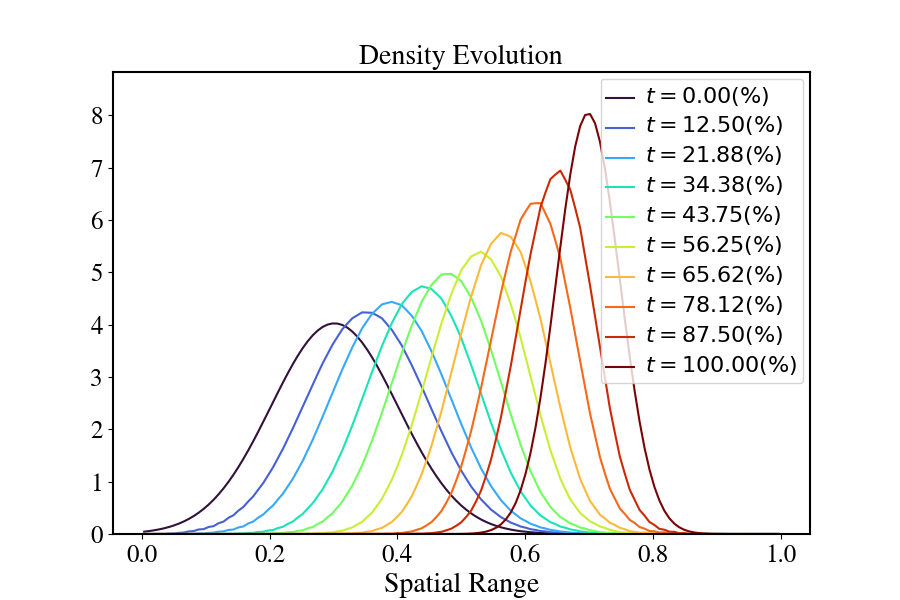

In [2]:
result, history = run_case(dim=1, density="gaussian")


## 2) DOT 2D

INFO - 🚀  Running DOT-SOCP | dim=2d | grid=(129x129x33) | levels=3 | density=example4 | delta=0.0 | weight=- | barrier=-

INFO - 🔥  Entering level 1/3 | Grid (33, 33, 9)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.22e-05, Time: 00:01, Iter: 414 (0.0038 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 414 with KKT error 9.22e-05

INFO - 🔥  Entering level 2/3 | Grid (65, 65, 17)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 8.96e-05, Time: 00:05, Iter: 239 (0.0222 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 239 with KKT error 8.96e-05

INFO - 🔥  Entering level 3/3 | Grid (129, 129, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.98e-05, Time: 00:26, Iter: 144 (0.1845 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 144 with KKT error 9.98e-05

INFO - ✅  Solver compl

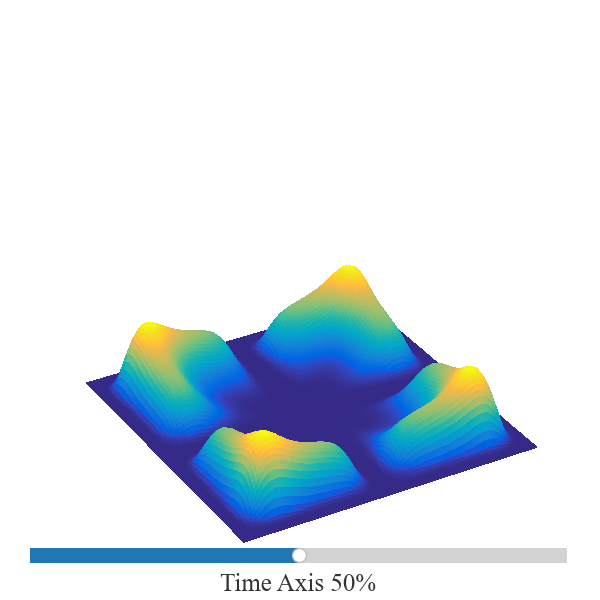

In [3]:
# Example 4: Quartic polynomial to four Gaussian mixture
result, history = run_case(dim=2, density="example4", plot_func="mesh")


INFO - 🚀  Running DOT-SOCP | dim=2d | grid=(257x257x33) | levels=3 | density=example6 | delta=0.0 | weight=- | barrier=-

INFO - 🔥  Entering level 1/3 | Grid (65, 65, 9)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.35e-05, Time: 00:02, Iter: 239 (0.0114 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 239 with KKT error 9.35e-05

INFO - 🔥  Entering level 2/3 | Grid (129, 129, 17)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.51e-05, Time: 00:12, Iter: 144 (0.0877 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 144 with KKT error 9.51e-05

INFO - 🔥  Entering level 3/3 | Grid (257, 257, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.55e-05, Time: 01:16, Iter: 114 (0.6636 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 114 with KKT error 9.55e-05

INFO - ✅  Solver com

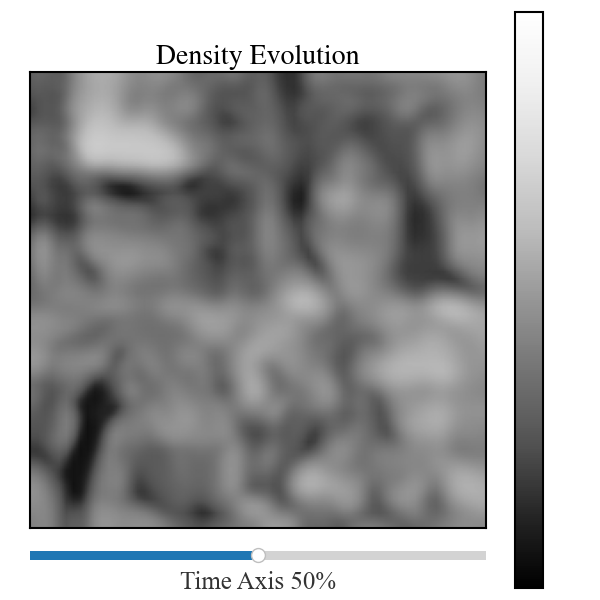

In [4]:
# DOTmark
import os
os.environ["DOTSOCP_EXAMPLE6_IMG_TYPE"] = "ClassicImages"
os.environ["DOTSOCP_EXAMPLE6_STITCH1"] = "1,2,3,4"
os.environ["DOTSOCP_EXAMPLE6_STITCH2"] = "5,6,7,8"
result, history = run_case(dim=2, density="example6", nt=33, nx=257, plot_func="imshow", plot_cmap="Greys_r")


## 3) Weighted DOT 2D (weight)


INFO - 🚀  Running DOT-SOCP | dim=2d | grid=(129x129x33) | levels=3 | density=example1 | delta=0.0 | weight=circular | barrier=-

INFO - 🔥  Entering level 1/3 | Grid (33, 33, 9)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 8.89e-05, Time: 00:02, Iter: 569 (0.0044 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 569 with KKT error 8.89e-05

INFO - 🔥  Entering level 2/3 | Grid (65, 65, 17)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.45e-05, Time: 00:07, Iter: 314 (0.0235 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 314 with KKT error 9.45e-05

INFO - 🔥  Entering level 3/3 | Grid (129, 129, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.73e-05, Time: 00:33, Iter: 214 (0.1572 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 214 with KKT error 9.73e-05

INFO - ✅  Solve

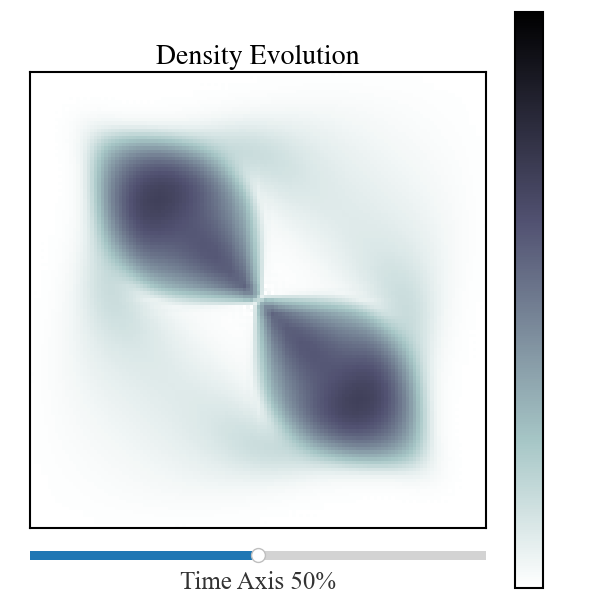

In [5]:
# Circular weight
result, history = run_case(dim=2, density="example1", weight="circular", plot_func="imshow", plot_cmap="bone_r")


## 4) Weighted DOT 2D (barrier)


INFO - 🚀  Running DOT-SOCP | dim=2d | grid=(129x129x33) | levels=3 | density=example9 | delta=0.0 | weight=- | barrier=circle-pillar

INFO - 🔥  Entering level 1/3 | Grid (33, 33, 9)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.57e-05, Time: 00:06, Iter: 1489 (0.0046 sec/it)]|██████████████████████████████████████████|100.0%
INFO - Converged at iter 1489 with KKT error 9.57e-05

INFO - 🔥  Entering level 2/3 | Grid (65, 65, 17)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.66e-05, Time: 00:27, Iter: 969 (0.0283 sec/it)]|███████████████████████████████████████████|100.0%
INFO - Converged at iter 969 with KKT error 9.66e-05

INFO - 🔥  Entering level 3/3 | Grid (129, 129, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 8.14e-05, Time: 02:38, Iter: 1009 (0.1569 sec/it)]|██████████████████████████████████████████|100.0%
INFO - Converged at iter 1009 with KKT error 8.14e-05

INFO - ✅

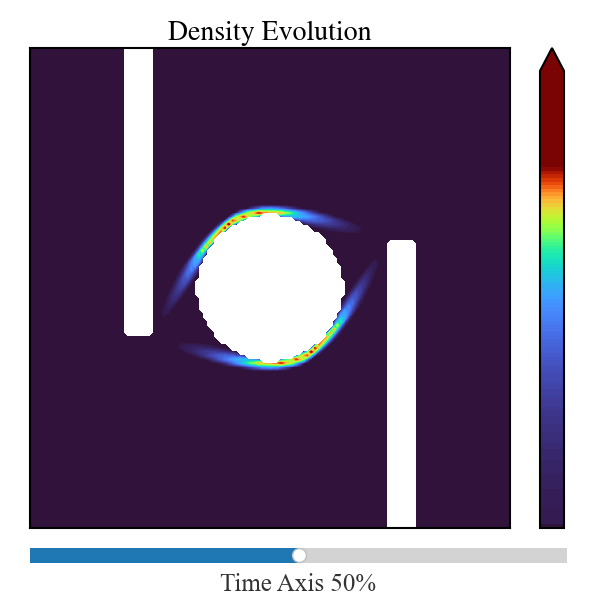

In [6]:
# Barrier in the shape of a circle and two pillars
result, history = run_case(dim=2, density="example9", barrier="circle-pillar", plot_func="contourf", plot_cmap="turbo")


INFO - 🚀  Running DOT-SOCP | dim=2d | grid=(129x129x33) | levels=3 | density=example9 | delta=0.0 | weight=- | barrier=maze

INFO - 🔥  Entering level 1/3 | Grid (33, 33, 9)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.98e-05, Time: 00:12, Iter: 3649 (0.0033 sec/it)]|██████████████████████████████████████████|100.0%
INFO - Converged at iter 3649 with KKT error 9.98e-05

INFO - 🔥  Entering level 2/3 | Grid (65, 65, 17)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.85e-05, Time: 00:52, Iter: 2609 (0.0200 sec/it)]|██████████████████████████████████████████|100.0%
INFO - Converged at iter 2609 with KKT error 9.85e-05

INFO - 🔥  Entering level 3/3 | Grid (129, 129, 33)
------------------------------------------------------------
[Tol=1.00e-04, Acc: 9.54e-05, Time: 03:08, Iter: 1249 (0.1505 sec/it)]|██████████████████████████████████████████|100.0%
INFO - Converged at iter 1249 with KKT error 9.54e-05

INFO - ✅  Solver

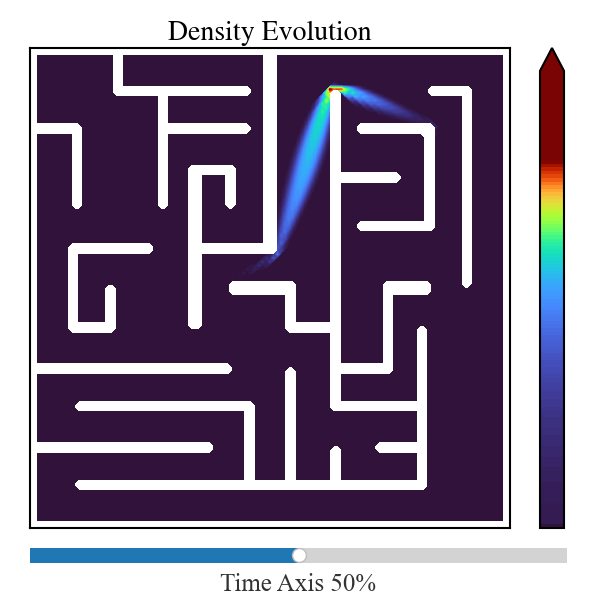

In [7]:
# Barrier in the shape of maze
result, history = run_case(dim=2, density="example9", barrier="maze", plot_func="contourf", plot_cmap="turbo")
